Predecir el coste del seguro médico de una persona

La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre medical_insurance_cost.csv. Puedes cargarlo en el código directamente desde el siguente enlace:

PARTE 1. 
1. CONOCIENDO EL DATASET

In [305]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
url="https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
df=pd.read_csv(url)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [306]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [307]:
df.shape

(1338, 7)

In [308]:
# revisando nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Conclusiones del dataset:
- el dataset tiene 1338 filas y 7 columnas
- No hay valores nulos
- Se visualizan 3 variables categóricas y 4 variables numéricas.

2. ELIMINACIÓN DE DUPLICADOS

In [309]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
df_duplicados = df[duplicados]
print("Filas duplicadas:")
print(df_duplicados)

# Eliminar duplicados
#usar el método drop.duplicated() para eliminar filas duplicadas

df = df.drop_duplicates().reset_index(drop=True)    

print ("="*80)

print(f"Shape sin duplicados: {df.shape}")

El dataset tiene 1 filas duplicadas
Filas duplicadas:
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631
Shape sin duplicados: (1337, 7)


Conclusión:
Se eliminó 1 fila duplicada, ahora el df tiene  1337 registros.

3. Selección de atributos relevantes

Se considera que para tener como variable objetivo charges, se considera que todas las 7 variables del dataset son importantes.

4. Análisis univariante

4.1. Análisis sobre variables categóricas

In [310]:
print(df.sex.value_counts())
print("="*80)
print(df.smoker.value_counts())
print("="*80)
print(df.region.value_counts())


sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


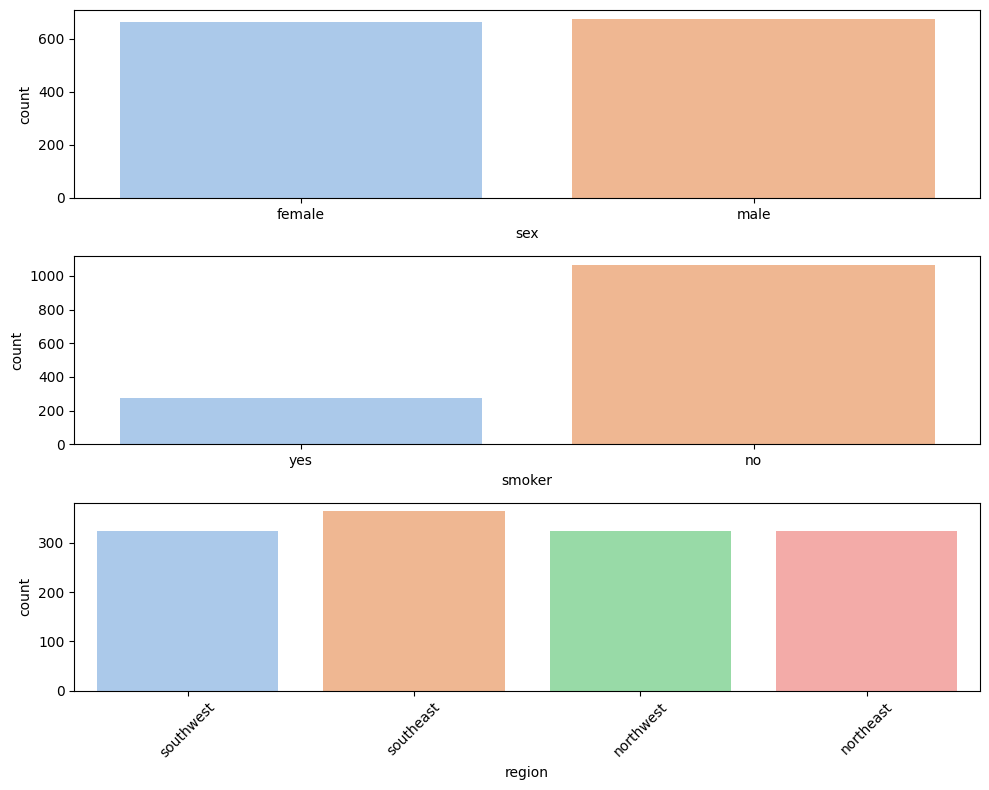

In [311]:
fig, axis = plt.subplots(3,1, figsize = (10,8))

sns.countplot(ax = axis[0], data = df, x = "sex", palette='pastel', hue= "sex", legend=False)
sns.countplot(ax = axis[1], data = df, x = "smoker", palette='pastel', hue= "smoker", legend=False)
sns.countplot(ax = axis[2], data = df, x = "region", palette='pastel', hue= "region", legend=False)
axis[2].tick_params(axis='x', rotation=45)
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Conclusiones:
- sex: Se visualizan volumne de datos equilibrado de ambos géneros.No hay un valor predominante en eel dataset.
- smoker: La gran mayoría de los clientes son no fumadores.
- region: Las 4 regiones del dataset presentan volumen equilibrado en datos. Se puede decir que sooutheast tiene más clientes, sin embargo no es tan predominante comparado a las demás zonas.

4.2. Análisis sobre análisis numéricas

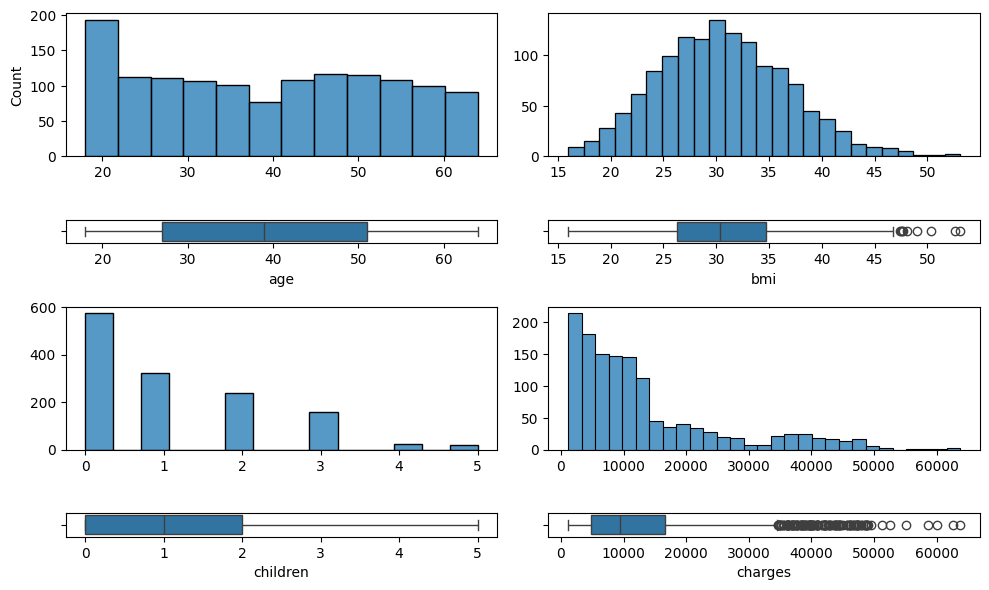

In [312]:
fig, axis = plt.subplots(4, 2, figsize = (10, 6), gridspec_kw={'height_ratios': [6,1,6,1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = df, x = "age").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "age")

sns.histplot(ax = axis[0, 1], data = df, x = "bmi").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "bmi")

sns.histplot(ax = axis[2, 0], data = df, x = "children").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "children")

sns.histplot(ax = axis[2, 1], data = df, x = "charges").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "charges")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()


conclusiones:
- Se visualiza que las variables que tienen valores atípicos son bmi y charges.
- age: 
Age muestra una distribución uniforme. existen valores entre 20 y 60.
- bmi: 
Aparentmente mestra una distribución normal, tiene mayoría de datos concentrados entre 25 y 35.
- children: 
Se visualliza fácilmente que laa mayoría de clientes no tienen hijos, existe solo valoes ded clientes conmáximo 5 hijos. Sin embargo, se ve sesgo a la derecha.
- charges: 
Tiene distribución sesgada a la derecha. esta variable es la target, por lo que los outliers y el sesgo son importantes a considerar para el modelo.

5. Análisis multivariante

5.1. Análisis numérico-numérico

charges- age, bmi, children

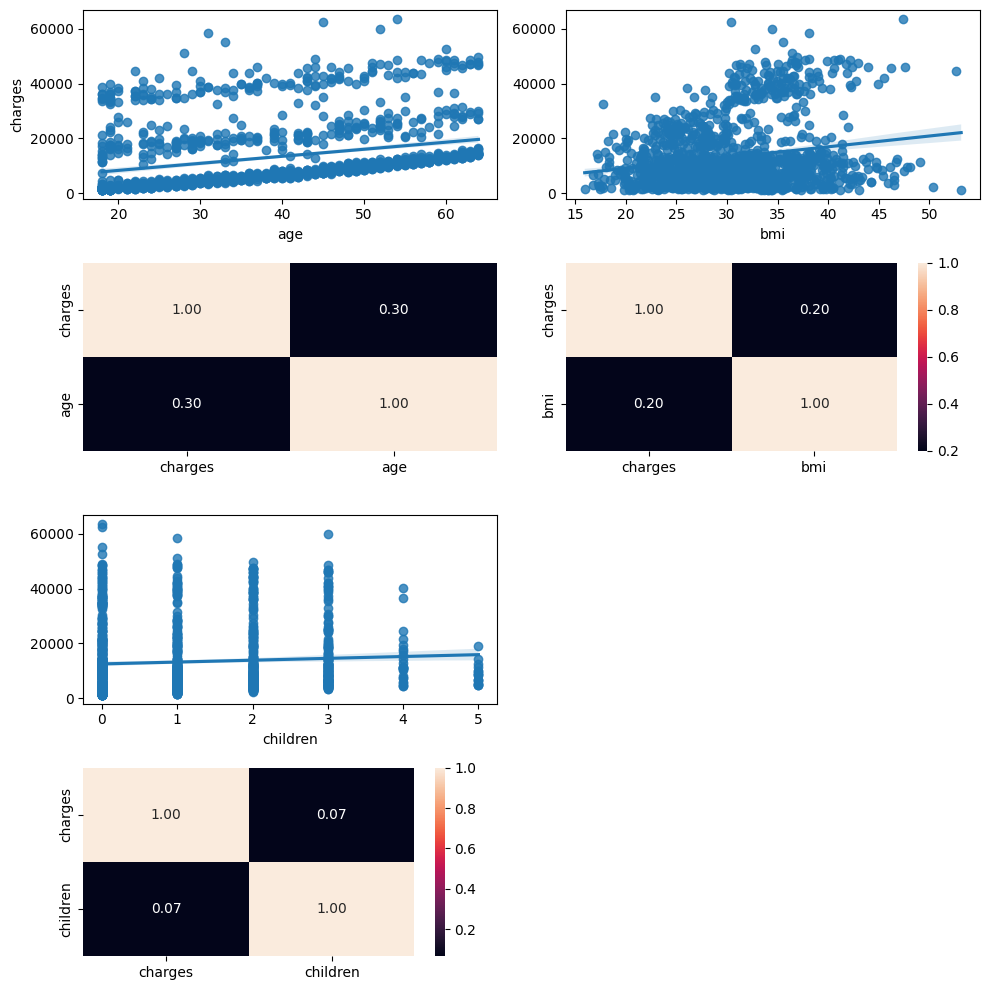

In [313]:
fig, axis = plt.subplots(4, 2, figsize = (10, 10))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "age", y = "charges")
sns.heatmap(df[["charges", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "bmi", y = "charges").set(ylabel=None)
sns.heatmap(df[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = df, x = "children", y = "charges").set(ylabel=None)
sns.heatmap(df[["charges", "children"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0])

axis[2, 1].set_visible(False)  
axis[3, 1].set_visible(False)  
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

conclusiones:
Se realiza el análisis de charges con las demás variables numéricas.
No se halla correlación fuerte con ninguna de las variables.
como la variable charges es la target, se prioriza el análisis de este con las demás variables numéricas.

6. Análisis catégorico-categórico

smoker- (sex, region)

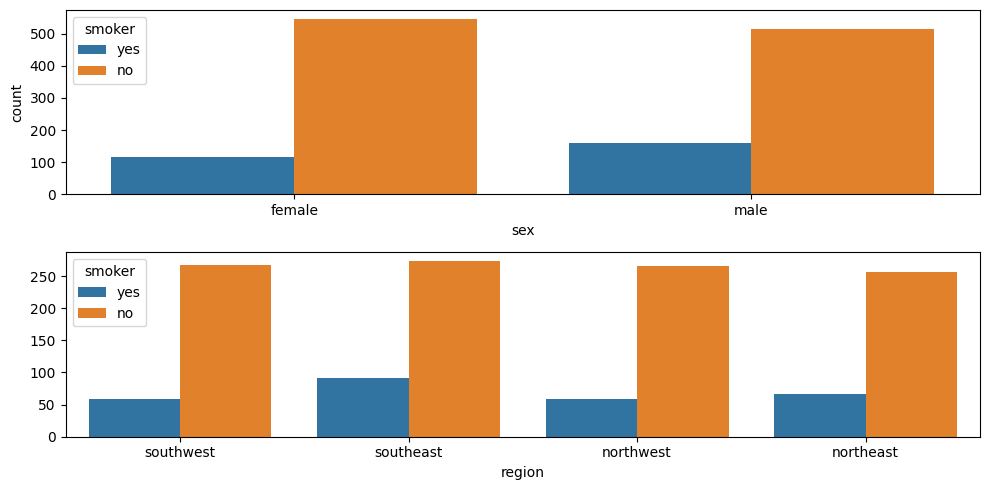

In [314]:
fig, axis = plt.subplots(2,1, figsize = (10, 5))

sns.countplot(ax = axis[0], data = df, x = "sex", hue = "smoker")
sns.countplot(ax = axis[1], data = df, x = "region", hue = "smoker").set(ylabel = None)


plt.tight_layout()


plt.show()


Conclusiones:
- Se analiza el volumne de clientes fumadores o no según sex y region. Ya que el objetivo es identificar el coste de prima de un sweguro. Se cree que para este criterio la variable emoker suena relevante.

- Se visualiza una proporción casi pareja entre fumadores female y male.  Sin embargo, predomina por poco la cantidad de clientes hombres fumadores.

- se puede decir que la región que tiene más fumadores es la de southeast

Análisis de correlaciones

In [315]:
#Se factoriza en variables categóricas
df["sex_n"] = pd.factorize(df["sex"])[0]
df["smoker_n"] = pd.factorize(df["smoker"])[0]
df["region_n"] = pd.factorize(df["region"])[0]

In [316]:
df.head()

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2


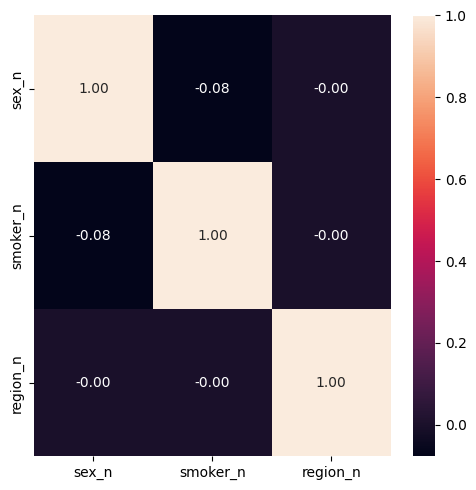

In [317]:
fig, axis = plt.subplots(figsize = (5, 5))

sns.heatmap(df[["sex_n","smoker_n","region_n"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

no se encuentra ninguna relación entre variables categóricas.

#### Análisis numérico-categórico (completo)

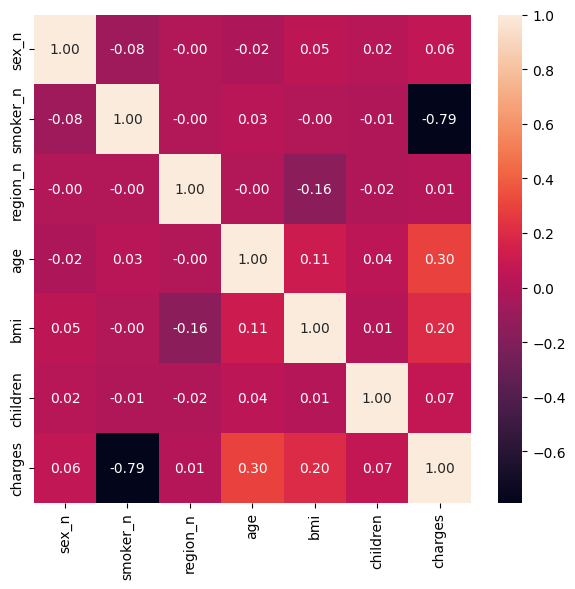

In [318]:
fig, axis = plt.subplots(figsize = (6, 6))

sns.heatmap(df[["sex_n","smoker_n","region_n","age","bmi","children","charges"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()


Se visualiza que no hay correlación fuerte enter las variables a exvepción de smoker-charges (-0.79)

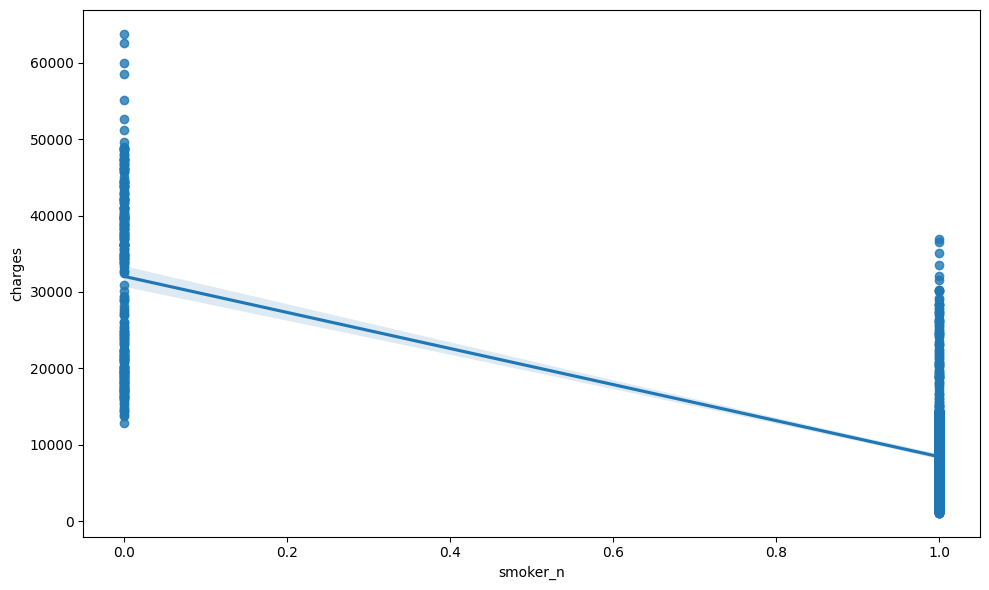

In [319]:
fig, axis = plt.subplots(figsize = (10, 6), ncols = 1)

sns.regplot(data = df, x = "smoker_n", y = "charges")


plt.tight_layout()

plt.show()

Se visualiza unarelación con tendencia negativa entre smoker y charges.
0 es si fumador, por lo que se puede decir que mientras sea el cliente fumador, el coste de la primera es mayor.

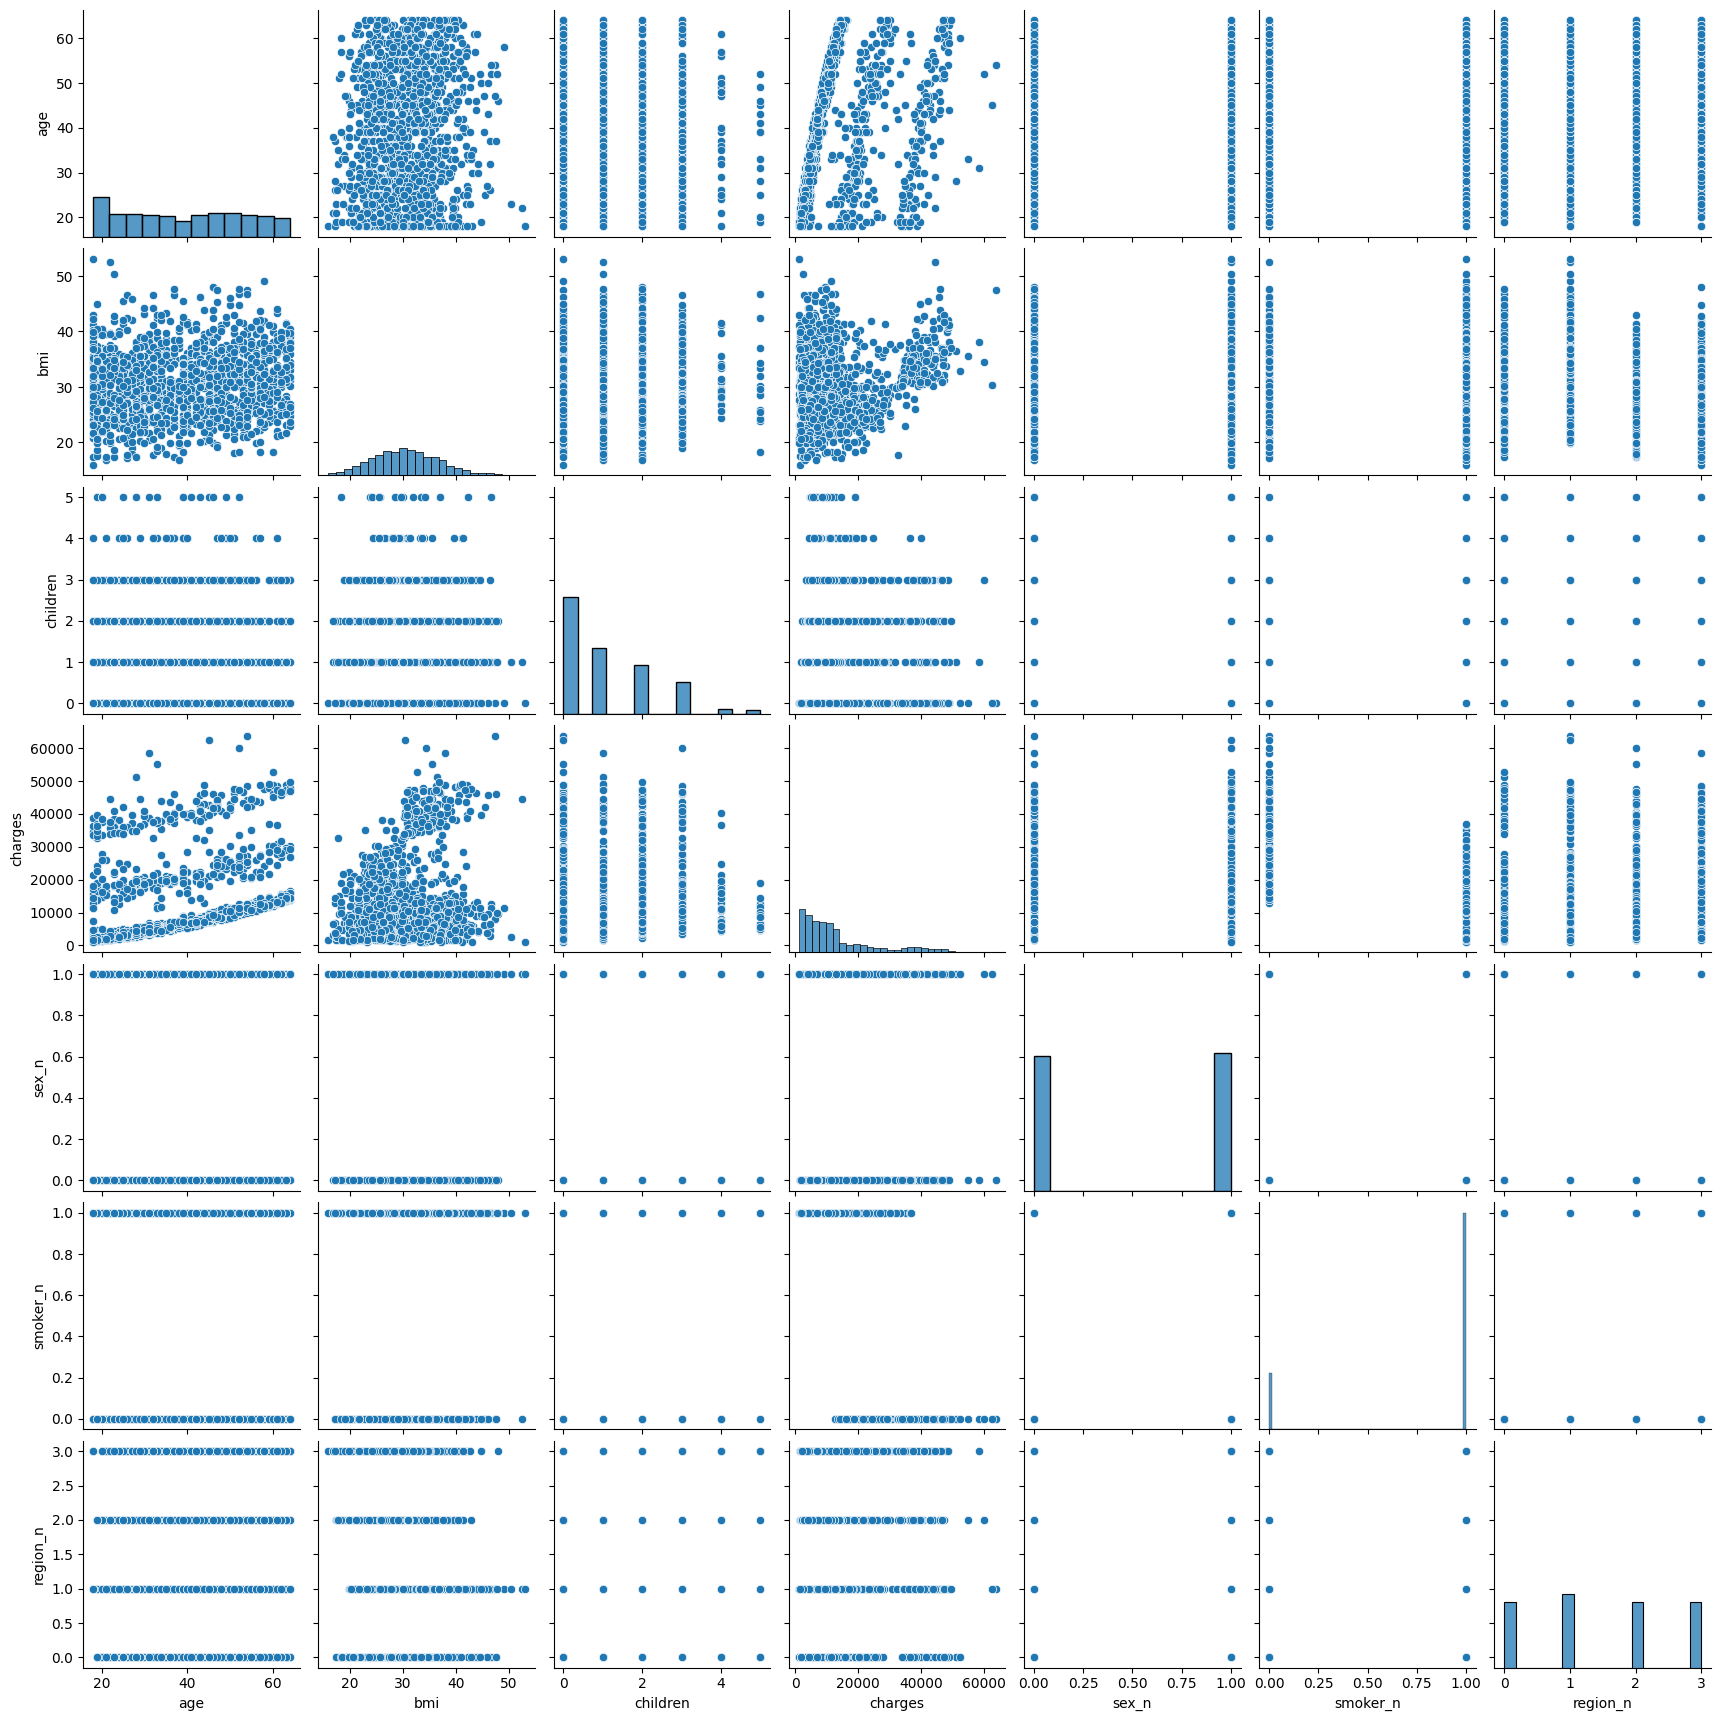

In [320]:
sns.pairplot(data = df)

PARTE 2

1. VALOES ATIPICOS

In [321]:
df.describe()

,age,bmi,children,charges,sex_n,smoker_n,region_n
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487,0.504862,0.795064,1.483919
std,14.044333,6.100468,1.205571,12110.359656,0.500163,0.403806,1.105208
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000
25%,27.000000,26.290000,0.000000,4746.344000,0.000000,1.000000,1.000000
50%,39.000000,30.400000,1.000000,9386.161300,1.000000,1.000000,1.000000
75%,51.000000,34.700000,2.000000,16657.717450,1.000000,1.000000,2.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000,3.000000


Los clientes tienen entre 18 y 64 años; y la media es 39 años.

bmi: Media de 30.6, pero tiene outliers ya que se encuentra un valor bmi muy alto (53.1).

children: En promedio los clientes tienen 1 hijo, como se visualizó en análisis de categóricas, hay clientes que tienen hasta 5 hijos. Probablmente no sea un outlier.

charges: La media de coste de prima es de 13279. sin embargo, existen valores máximo hasta 63770, habría que considerar que esta variable tiene outliers. A su vez, se confirma el sesgo a la derecha.

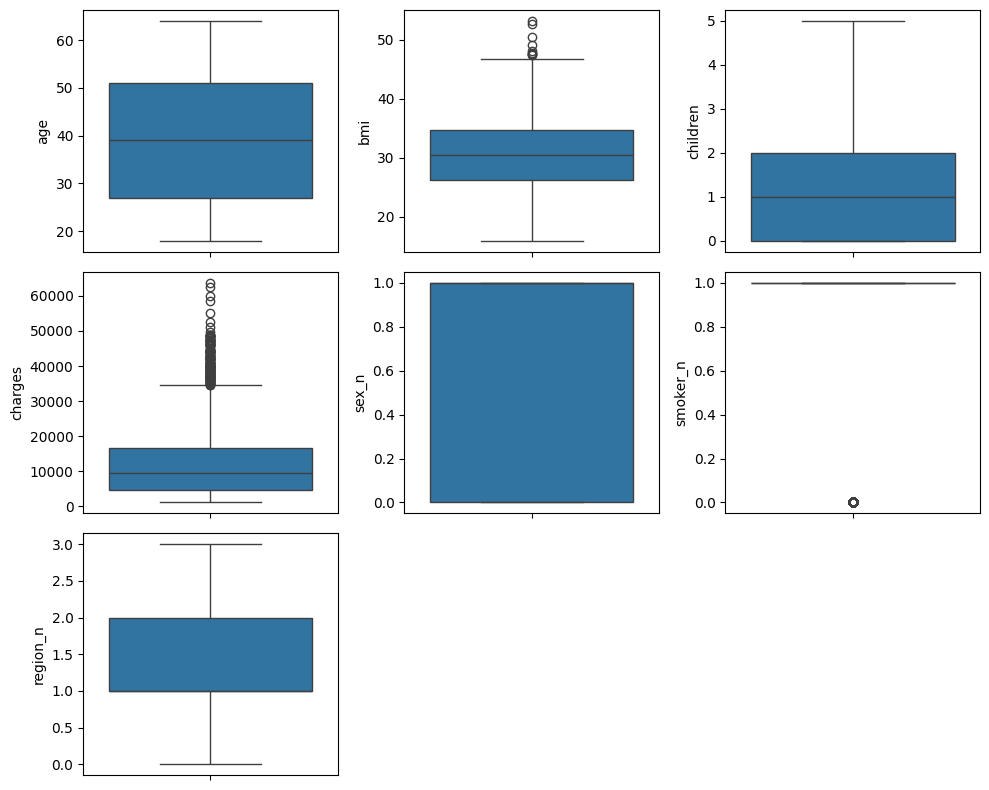

In [322]:
fig, axis = plt.subplots(3, 3, figsize = (10, 8))

sns.boxplot(ax = axis[0, 0], data = df, y = "age")
sns.boxplot(ax = axis[0, 1], data = df, y = "bmi")
sns.boxplot(ax = axis[0, 2], data = df, y = "children")
sns.boxplot(ax = axis[1, 0], data = df, y = "charges")
sns.boxplot(ax = axis[1, 1], data = df, y = "sex_n")
sns.boxplot(ax = axis[1, 2], data = df, y = "smoker_n")
sns.boxplot(ax = axis[2, 0], data = df, y = "region_n")

fig.delaxes(axis[2, 1])
fig.delaxes(axis[2, 2])

plt.tight_layout()

plt.show()


Se tomará en cuenta hacer un estudio de outliers en charges y bmi.

atípicos- charges

In [323]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 34524.78 y -13120.72, con un rango intercuartílico de 11911.37


Aquí se tiene que se considera outlier si los valores de charges superan 34524.78. A continuación se revisará el volumen de estos "outliers"

In [324]:
charges_altos = df[df["charges"] >= 34524.78]

charges_altos

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
14,27,male,42.130,0,yes,southeast,39611.75770,1,0,1
19,30,male,35.300,0,yes,southwest,36837.46700,1,0,0
23,34,female,31.920,1,yes,northeast,37701.87680,0,0,3
29,31,male,36.300,2,yes,southwest,38711.00000,1,0,0
30,22,male,35.600,0,yes,southwest,35585.57600,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1299,45,male,30.360,0,yes,southeast,62592.87309,1,0,1
1300,62,male,30.875,3,yes,northwest,46718.16325,1,0,2
1302,43,male,27.800,0,yes,southwest,37829.72420,1,0,0
1312,19,female,34.700,2,yes,southwest,36397.57600,0,0,0


Los valores outliers resultan ocupar 139 filas, lo qeu equivale a un 10% del dataset.
Se puede interprtar que smoker es una variable que puede influir en el coste de prima, en este caso, se evaluará cuantos son fumadores de los 139 outliers.
Además se recuerdad que charges-smoker tenian una correlación fuerte negativa de -0.79.

In [325]:
charges_altos.smoker.value_counts()

smoker
yes    136
no       3
Name: count, dtype: int64

Si considera como outliers valores mayores a 34k, y se decide  mantenerlos, porque estos además de ocupar el 10% del dataset, y como esta variable tiene relación fuerte con smoker, más del 90% de esos registros son fumadores.  Se considera no realizar otro estudio de extrermos.

atípicos- BMI

In [326]:
Q1_ = df['bmi'].quantile(0.25)
Q3_ = df['bmi'].quantile(0.75)
IQR_ = Q3_ - Q1_

# Definir los límites inferior y superior
lower_limit_ = Q1_ - 1.5 * IQR_
upper_limit_ = Q3_ + 1.5 * IQR_

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_, 2)} y {round(lower_limit_, 2)}, con un rango intercuartílico de {round(IQR_, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 47.32 y 13.67, con un rango intercuartílico de 8.41


outliers serian los bmi mayores a 47.32. A continuación se revisará el volumen de data.

In [327]:
bmi_altos = df[df["bmi"] >= 47.32]

bmi_altos

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
116,58,male,49.06,0,no,southeast,11381.32540,1,1,1
286,46,female,48.07,2,no,northeast,9432.92530,0,1,3
401,47,male,47.52,1,no,southeast,8083.91980,1,1,1
543,54,female,47.41,0,yes,southeast,63770.42801,0,0,1
846,23,male,50.38,1,no,southeast,2438.05520,1,1,1
859,37,female,47.60,2,yes,southwest,46113.51100,0,0,0
1046,22,male,52.58,1,yes,southeast,44501.39820,1,0,1
1087,52,male,47.74,1,no,southeast,9748.91060,1,1,1
1316,18,male,53.13,0,no,southeast,1163.46270,1,1,1


In [328]:
bmi_altos.smoker.value_counts()

smoker
no     6
yes    3
Name: count, dtype: int64

Si bien los 9 registros considerados ouotliers por tener bmi>47.32 ocupan 1% del dataset, el índice de masa muscular puede ser real y no errores de medición. por lo que se decide mantnere los 9 registros, además esto no afecta significativamente el modelo predictivo.

Cconclusión final,, no se eliminaron valores atípicos.

2. Valores faltantes

In [329]:
df.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
sex_n       0
smoker_n    0
region_n    0
dtype: int64

No existen valores faltantes enel dataset

3. ingeniereía de atributos 

Se plantea clasificar los valores bmi según la clasificación de la oms.

El criterio sería el siguiente:

bajo_peso: BMI menor a 18.5

normal: BMI entre 18.5 y 24.9

sobrepeso: BMI entre 25.0 y 29.9

obesidad_grado1: BMI entre 30.0 y 34.9

obesidad_grado2: BMI entre 35.0 y 39.9

obesidad_grado3: BMI de 40.0 o más


In [330]:
def clasificar_bmi(bmi):
    if bmi < 18.5:
        return "bajo_peso"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "sobrepeso"
    elif bmi < 35:
        return "obesidad_grado1"
    elif bmi < 40:
        return "obesidad_grado2"
    else:
        return "obesidad_grado3"

df['bmi_categoria'] = df['bmi'].apply(clasificar_bmi)


print(df['bmi_categoria'].value_counts())

bmi_categoria
obesidad_grado1    390
sobrepeso          386
normal             225
obesidad_grado2    225
obesidad_grado3     91
bajo_peso           20
Name: count, dtype: int64


In [331]:
df.head()

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n,bmi_categoria
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0,sobrepeso
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1,obesidad_grado1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1,obesidad_grado1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2,normal
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2,sobrepeso


3. train/test split

Dividir el dataset en train y test

80% → entrenamiento

20% → prueba

In [332]:
X=df.drop("charges",axis=1)   #variable predictora
y=df["charges"]               #variable objetivo


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.head()

,age,sex,bmi,children,smoker,region,sex_n,smoker_n,region_n,bmi_categoria
1113,23,male,24.510,0,no,northeast,1,1,3,normal
967,21,male,25.745,2,no,northeast,1,1,3,sobrepeso
598,52,female,37.525,2,no,northwest,0,1,2,obesidad_grado2
170,63,male,41.470,0,no,southeast,1,1,1,obesidad_grado3
275,47,female,26.600,2,no,northeast,0,1,3,sobrepeso


In [333]:
X_train.shape, X_test.shape

((1069, 10), (268, 10))

4. escalado

Se realiza el escalado de variables numéricas mediante `StandardScaler`, con el fin de normalizar los datos y llevarlos a una escala comparable.

In [334]:
num_variables = [

    "age",
    "bmi",
    "children"
]

In [335]:
# instancio el escalador
scaler = StandardScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_scal = scaler.transform(X_train[num_variables])
X_train_num_scal = pd.DataFrame(X_train_num_scal, index = X_train.index, columns = num_variables)

X_test_num_scal = scaler.transform(X_test[num_variables])
X_test_num_scal = pd.DataFrame(X_test_num_scal, index = X_test.index, columns = num_variables)

X_train_num_scal.head()

,age,bmi,children
1113,-1.157680,-0.996928,-0.907908
967,-1.300619,-0.792762,0.766904
598,0.914926,1.154664,0.766904
170,1.701087,1.806837,-0.907908
275,0.557580,-0.651417,0.766904


In [336]:
# instancio el escalador
scaler = MinMaxScaler()

# entreno el escalador con los datos de entrenamiento

scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_mm = scaler.transform(X_train[num_variables])
X_train_num_mm = pd.DataFrame(X_train_num_mm, index = X_train.index, columns = num_variables)

X_test_num_mm = scaler.transform(X_test[num_variables])
X_test_num_mm = pd.DataFrame(X_test_num_mm, index = X_test.index, columns = num_variables)

X_train_num_mm.head()

,age,bmi,children
1113,0.108696,0.230024,0.0
967,0.065217,0.263250,0.4
598,0.739130,0.580172,0.4
170,0.978261,0.686306,0.0
275,0.630435,0.286252,0.4


5. encoding

Se utilizará la técnica one-hot encoding por que las vairbales no tienen un orden natural

In [337]:
cat_variables = [
    "sex",
    "smoker",
    "region",
    "bmi_categoria"  # la nueva de ingnieria de atributos
]

In [338]:
# instancio el encoder

onehot_encoder = OneHotEncoder(sparse_output=False)

# entreno el encoder con los datos de entrenamiento
onehot_encoder.fit(X_train[cat_variables])

# aplico el encoder en amhos
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index = X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index = X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_categoria_bajo_peso,bmi_categoria_normal,bmi_categoria_obesidad_grado1,bmi_categoria_obesidad_grado2,bmi_categoria_obesidad_grado3,bmi_categoria_sobrepeso
1113,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
967,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
598,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
170,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
275,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


PARTE 3-EDA

1. Selección de características

En esta parte se usa estadístico de prueba para seleccionar las variables importantes


unificar dataset preprocesado

In [339]:
# unificamos el dataset preprocesado hasta el momento
X_train_final = pd.concat([X_train_num_scal, X_train_cat_ohe], axis=1)
X_test_final = pd.concat([X_test_num_scal, X_test_cat_ohe], axis=1)

X_train_final.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_categoria_bajo_peso,bmi_categoria_normal,bmi_categoria_obesidad_grado1,bmi_categoria_obesidad_grado2,bmi_categoria_obesidad_grado3,bmi_categoria_sobrepeso
1113,-1.157680,-0.996928,-0.907908,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
967,-1.300619,-0.792762,0.766904,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
598,0.914926,1.154664,0.766904,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
170,1.701087,1.806837,-0.907908,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
275,0.557580,-0.651417,0.766904,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [340]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 1069 entries, 1113 to 1126
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1069 non-null   float64
 1   bmi                            1069 non-null   float64
 2   children                       1069 non-null   float64
 3   sex_female                     1069 non-null   float64
 4   sex_male                       1069 non-null   float64
 5   smoker_no                      1069 non-null   float64
 6   smoker_yes                     1069 non-null   float64
 7   region_northeast               1069 non-null   float64
 8   region_northwest               1069 non-null   float64
 9   region_southeast               1069 non-null   float64
 10  region_southwest               1069 non-null   float64
 11  bmi_categoria_bajo_peso        1069 non-null   float64
 12  bmi_categoria_normal           1069 non-null   float64
 13  b

Como charges es la variable a predecir, se utilizar el estadistico ded prueba f-regression

In [341]:

# Seleccionar las 20 variables más importantes
selection_model = SelectKBest(score_func = f_regression, k = 17)

# Entrenar el selector
selection_model.fit(X_train_final, y_train)

# Obtener columnas seleccionadas
ix = selection_model.get_support()

# Transformar datasets
X_train_sel = pd.DataFrame(selection_model.transform(X_train_final),columns = X_train_final.columns.values[ix],index = X_train_final.index)

X_test_sel = pd.DataFrame(selection_model.transform(X_test_final),columns = X_test_final.columns.values[ix],
    index = X_test_final.index)

X_train_sel.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_categoria_bajo_peso,bmi_categoria_normal,bmi_categoria_obesidad_grado1,bmi_categoria_obesidad_grado2,bmi_categoria_obesidad_grado3,bmi_categoria_sobrepeso
1113,-1.157680,-0.996928,-0.907908,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
967,-1.300619,-0.792762,0.766904,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
598,0.914926,1.154664,0.766904,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
170,1.701087,1.806837,-0.907908,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
275,0.557580,-0.651417,0.766904,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [342]:
# Obtener las características seleccionadas
selected_features = X_train_final.columns[selection_model.get_support()]

selected_features

Index(['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no',
       'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_categoria_bajo_peso',
       'bmi_categoria_normal', 'bmi_categoria_obesidad_grado1',
       'bmi_categoria_obesidad_grado2', 'bmi_categoria_obesidad_grado3',
       'bmi_categoria_sobrepeso'],
      dtype='str')

In [343]:
X_train_sel["charges"] = y_train.values
X_test_sel["charges"] = y_test.values

X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

MODELADO

#### Paso 1. Lectura del conjunto de datos procesado

In [344]:
#traer la data preprocesada
train_data=pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_categoria_bajo_peso,bmi_categoria_normal,bmi_categoria_obesidad_grado1,bmi_categoria_obesidad_grado2,bmi_categoria_obesidad_grado3,bmi_categoria_sobrepeso,charges
0,-1.157680,-0.996928,-0.907908,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2396.09590
1,-1.300619,-0.792762,0.766904,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3279.86855
2,0.914926,1.154664,0.766904,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,33471.97189
3,1.701087,1.806837,-0.907908,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13405.39030
4,0.557580,-0.651417,0.766904,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9715.84100


In [345]:
train_data.shape

(1069, 18)

separa x,y

In [346]:
# Separar X e y
X_train = train_data.drop(["charges"], axis = 1)
y_train = train_data["charges"]

X_test = test_data.drop(["charges"], axis = 1)
y_test = test_data["charges"]

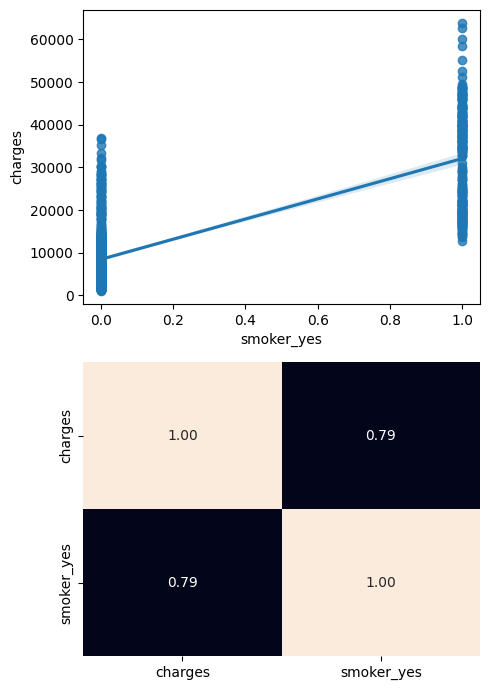

In [347]:
fig, axis = plt.subplots(2, 1, figsize = (5, 7))
total_data = pd.concat([train_data, test_data])

sns.regplot(ax = axis[0], data = total_data, x = "smoker_yes", y = "charges")

sns.heatmap(total_data[["charges", "smoker_yes"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)

plt.tight_layout()

plt.show()

Se visualiza la relación fuerte que se había encontrado en el EDA.

#### Paso 2: Inicialización y entrenamiento del modelo

In [348]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [349]:
X_train

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_categoria_bajo_peso,bmi_categoria_normal,bmi_categoria_obesidad_grado1,bmi_categoria_obesidad_grado2,bmi_categoria_obesidad_grado3,bmi_categoria_sobrepeso
0,-1.157680,-0.996928,-0.907908,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.300619,-0.792762,0.766904,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.914926,1.154664,0.766904,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.701087,1.806837,-0.907908,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.557580,-0.651417,0.766904,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064,0.843457,0.730628,0.766904,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1065,-0.871804,2.539188,0.766904,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1066,-1.372088,-1.411872,-0.070502,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1067,-0.085643,-0.419974,1.604310,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [350]:
print(f"Intercepto (b0): {model.intercept_}")
print(f"Coeficientes (b1, b2): {model.coef_}")

Intercepto (b0): 19440.74562716053
Coeficientes (b1, b2): [  3434.41040852    221.69425606    663.04533222     32.76196236
    -32.76196236 -11531.21726014  11531.21726014    489.0198418
     29.88142843   -212.95546237   -305.94580786  -4340.56399635
  -1615.3614923    2098.95144094   2988.41105137   2172.33392408
  -1303.77092774]


#### Paso 3: Predicción del modelo

In [351]:
y_pred = model.predict(X_test)
y_pred

array([ 8.26017873e+03,  5.26725468e+03,  1.51352914e+04,  3.22605363e+04,
        9.43608499e+03,  1.38220143e+04,  3.12393453e+04,  9.68885155e+02,
        1.17910381e+04,  1.00046573e+04,  1.07597925e+04,  3.20889966e+04,
        3.18267990e+04,  1.50513047e+04,  1.11745906e+04,  8.13214033e+03,
        5.00085555e+03,  3.30536413e+04,  2.97366587e+03,  3.84076257e+03,
        4.60413160e+03,  2.92004732e+04,  1.32609399e+04,  2.91519498e+04,
        3.20824948e+04,  6.22598873e+03,  3.45205322e+04,  3.73189020e+04,
        1.28981634e+04,  1.53199269e+04,  7.93518930e+03,  1.34961047e+04,
        5.33855111e+02,  1.09692855e+04,  3.66135235e+04,  1.27194486e+04,
        3.47789692e+03,  4.77463697e+03,  3.15432667e+04,  7.95704859e+03,
        6.93587656e+03,  3.09353619e+04,  3.59105195e+04,  1.33792560e+04,
        8.14667077e+03,  2.80817724e+03,  5.15539002e+03,  7.19549664e+03,
        3.70419040e+03,  1.02885309e+04,  7.67824405e+03,  1.03314536e+04,
        3.08832088e+04,  

#### Paso 4: Evaluación del modelo

In [352]:
print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 36287693.2837647
Coeficiente de determinación: 0.8025224719895584


Con el valor R2 rsultante 0.80 es un valor alto, por lo que se deduce como satisfactorio.  Los datos están explicados por el modelo.

#### Paso 5: Optimización de resultados

REGRESION LINEAL

In [353]:
# modelo
reg_lin = LinearRegression()

# entrenamiento
reg_lin.fit(X_train, y_train)

# predicción
y_pred = reg_lin.predict(X_test)
y_pred

# metricas
mse_rl = mean_squared_error(y_test, y_pred)
rmse_rl = np.sqrt(mse_rl)
r2_rl = r2_score(y_test, y_pred)

print("MSE: ", mse_rl)
print("RMSE: ", rmse_rl)
print("Coeficiente de determinación: ", r2_rl)

MSE:  36287693.2837647
RMSE:  6023.926732934648
Coeficiente de determinación:  0.8025224719895584


REGULARIZACIÓN LASSO

In [354]:
# modelo
reg_lasso = Lasso(alpha = 0.2, max_iter = 400)

# entrenamiento
reg_lasso.fit(X_train, y_train)

# prediccion
y_pred = reg_lasso.predict(X_test)
y_pred

# metricas
mse_l1 = mean_squared_error(y_test, y_pred)
rmse_l1 = np.sqrt(mse_l1)
r2_l1 = r2_score(y_test, y_pred)

print("MSE: ", mse_l1)
print("RMSE: ", rmse_l1)
print("Coeficiente de determinación: ", r2_l1)

MSE:  36283678.88445576
RMSE:  6023.593519192324
Coeficiente de determinación:  0.8025443183396633


### Regularización Ridge

In [355]:
# modelo
reg_ridge = Ridge(alpha = 0.2, max_iter = 400)

# entrenamiento
reg_ridge.fit(X_train, y_train)

# prediccion
y_pred = reg_ridge.predict(X_test)
y_pred

# metricas
mse_l2 = mean_squared_error(y_test, y_pred)
rmse_l2 = np.sqrt(mse_l2)
r2_l2 = r2_score(y_test, y_pred)

print("MSE: ", mse_l2)
print("RMSE: ", rmse_l2)
print("Coeficiente de determinación: ", r2_l2)

MSE:  36282181.87570564
RMSE:  6023.469255811441
Coeficiente de determinación:  0.8025524650572039


### Resultados

In [356]:
# Datos
data = {
    'Modelo': ['Regresión lineal', "Regulación Lasso", "Regulación Ridge"],
    'MSE': [mse_rl, mse_l1, mse_l2],
    'RMSE': [rmse_rl, rmse_l1, rmse_l2],
    'R²': [r2_rl, r2_l1, r2_l2]
}

# Crear el DataFrame
resultados = pd.DataFrame(data)

# Mostrar el DataFrame
print(resultados)

             Modelo           MSE         RMSE        R²
0  Regresión lineal  3.628769e+07  6023.926733  0.802522
1  Regulación Lasso  3.628368e+07  6023.593519  0.802544
2  Regulación Ridge  3.628218e+07  6023.469256  0.802552


conclusiones finales:

Debido a que tnemos muchahs variables en el dataset, se utiliza la regresion linneal multiple.

para la parte de optimización del modelo, se probaron 3, R. lineal, r lasso y ridge. Estos 3 dieron el valor R2 muy similar (0.8). El modelo explica el 80% de la variabilidad  de charges.

Si bien se tiene un valor R2 algo (0.8) el RMSE es muy alto, esto quiere decir que se puede confundir en los resultados con una diferencia de 6000 dóalres, lo cual perjudica en el objeetivo del ejercicio.

Si tuvieramos que escoger un modelo de los 3, se escogería la de ridge, ya que el valor rmse es menor pero no por mucha diferencia.

El rmse significa  que en promedio el modelo se equivoca en 6000$ en el coste de prima. Lo cual se puede interpretar como preocupante.

Si bien se logró que el modelo explique bien un 80% de los costos de prima, sin embargo, hay un RMSE muy alto, esto puede deberse a que el dataset en charges tenia valores muy altos. En el EDA se encontró que los fumadores  son un factor importante que immpacta en el costo de prima.